# Feature selection experience

This notebook explores the contribution of each feature to predict close price in both scenario, binary classification and regression

## 1. Set up

We first set up the environment for experiment. This step include

1. Import all dependencies
2. Declare global environment to config the experiment
3. Declare all support functions needed for the experiment

### 1.1 Import all dependencies

This experiment requires the following libraries to run
- torch
- sklearn
- numpy

In [1]:
from src.data import Dataloader
import pandas as pd
import os
from src.utils import seed_everything
import random
from tqdm import tqdm
from typing import Callable
import torch.nn.functional as F
from src.data import TimeSeriesDataset
import torch
from sklearn.metrics import roc_auc_score, precision_score
import warnings
from sklearn.exceptions import DataConversionWarning

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import copy

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
import warnings

import pmdarima as pm
from typing import Tuple


### 1.2 Declare global environment to config the experiment

This section below will set up constant needed for experiment

In [73]:
# Clean data location
DATA_PATH = os.path.abspath('data/clean/')

# Path to where we cache the result
RESULT_PATH = os.path.abspath('data/results/')

# Train, validation and test split
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15  

# Columns that are used as features for training
ALL_FEAT_COLUMN = ['Close','High','Low', 'Open','Volume','sentiment_score_mean','sentiment_polarity_mean','sentiment_subjectivity_mean','news_count', 'log_return', 'vol_7d','vol_30d','ma_7','ma_30','ma_ratio']

# Columns that are used as features for training but do NOT need to normalize
ALREADY_NORMALIZE_FEAT = ['sentiment_score_mean','sentiment_polarity_mean','sentiment_subjectivity_mean','news_count','ma_ratio','log_return']

# Label for binary classification task
BINARY_LABEL_COLUMN = 'price_increase'

# Label for regression task
REGRESSION_LABEL_COLUMN = 'next_close'

# Number of tokens used in training to demonstrate scaling laws
LOG_SCALING = [2,4,8,16,32]

# For reproducibility, inital random seed
INIT_SEED = 720

# Force re-run. To save time, we load the results (if they have been already generated by previous run.
# If the results have not yet computed or `RE_RUN_EVERYTHING` is set to True, the following script re-generate everything
RE_RUN_EVERYTHING = False

seed_everything(INIT_SEED)

files = os.listdir(DATA_PATH)[:3]


### 1.3. Declare all support functions needed for the experiment

To conduct experiment, we define the following support functions

1. `normalize`: normalize continuous features for training
2. `binary_classfication_model_experience`: Given each token dataset, run all baseline for binary classification task
3. `regression_classfication_model_experience`: Given each token dataset, run all baseline for regression classification task
4. `drop_feature_experiment` : conduct experiment to study importance of features by dropping each of them one by one

In [4]:
def normalize(train_data: TimeSeriesDataset, valid_data: TimeSeriesDataset, test_data: TimeSeriesDataset, normalize_y = False, exclude_cols = []):
    r"""
    Normalize each feature in training, validation and testing data with max and min of the feature from training data.

    Args:
    - `train_data` (TimeSeriesDataset): data split for training
    - `valid_data` (TimeSeriesDataset): data split for validation
    - `test_data` (TimeSeriesDataset): data split for testing
    - `normalize_y` (bool): whether to normalize input (True for regresison case and False for binary classification case)
    - `exclude_cols` (list): columns that don't need to normalize

    Return:
    - data splits for training, validation and testing with normalized features
    """
    n_cols = train_data.x.shape[1]
    include_cols = [i for i in range(n_cols) if i not in (exclude_cols or [])]

    max_values, _ = torch.max(train_data.x[:, include_cols], dim=0)
    min_values, _ = torch.min(train_data.x[:, include_cols], dim=0)

    denom = (max_values - min_values)
    denom[denom == 0] = 1  # avoid division by zero

    for data in [train_data, valid_data, test_data]:
        data.x[:, include_cols] = (data.x[:, include_cols] - min_values) / denom

    if normalize_y:
        max_y, _ = torch.max(train_data.y, dim=0)
        min_y, _ = torch.min(train_data.y, dim=0)
        for data in [train_data, valid_data, test_data]:
            data.y = (data.y - min_y) / (max_y - min_y)

    return train_data, valid_data, test_data

In [5]:
def binary_classfication_model_experience(train_data: TimeSeriesDataset, test_data: TimeSeriesDataset):
    r"""
    Train and evaluate multiple binary classification baseline models on time series data.

    Each model is trained on the training split and evaluated on the test split using
    ROC-AUC score as the performance metric. C
    Args:
    - `train_data` (TimeSeriesDataset): data split for training
    - `test_data` (TimeSeriesDataset): data split for testing

    Return:
    - `results` (dict): dictionary mapping model name to its ROC-AUC score on the test split
    """
    train_x = train_data.x.numpy()
    train_y = train_data.y.squeeze().numpy()
    test_x = test_data.x.numpy()
    test_y = test_data.y.squeeze().numpy()

    models = {
        "Logistic Regression":     LogisticRegression(),
        "Random Forest":           RandomForestClassifier(),
        "Gradient Boosting (GBM)": GradientBoostingClassifier(),
        "SVM":                     SVC(probability=True),
        "KNN":                     KNeighborsClassifier(),
    }
    results = {}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for name, model in models.items():
            model.fit(train_x, train_y)
            preds = model.predict_proba(test_x)[:, 1]
            auc = roc_auc_score(test_y, preds)
            results[name] = auc

    return results

In [6]:
def regression_classfication_model_experience(train_data, test_data):
    r"""
    Train and evaluate multiple regression baseline models on time series data.

    Each model is trained on the training split and evaluated on the test split using
    Root Mean Squared Error (RMSE) as the performance metric.

    Args:
    - `train_data` (TimeSeriesDataset): data split for training
    - `test_data` (TimeSeriesDataset): data split for testing

    Return:
    - `results` (dict): dictionary mapping model name to its RMSE score on the test split
    """
    train_x = train_data.x.numpy()
    train_y = train_data.y.squeeze().numpy()
    test_x = test_data.x.numpy()
    test_y = test_data.y.squeeze().numpy()

    models = {
        "Linear Regression":       LinearRegression(),
        "Ridge":                   Ridge(alpha=1.0),
        "Lasso":                   Lasso(alpha=0.1),
        "Random Forest":           RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting (GBM)": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "SVR":                     SVR(),
    }

    results = {}
    for name, model in models.items():
        model.fit(train_x, train_y)
        preds = model.predict(test_x)
        results[f"{name}"] = np.sqrt(mean_absolute_percentage_error(test_y, preds))

    return results


In [7]:
def prepare_datasets(files: list[str], feat_cols: list[str], task : str):
    """r
    Load, split, and normalize multiple time series datasets from CSV files.

    For each file, loads the data with the specified feature and label columns,
    splits it into train/val/test sets according to the global TRAIN_RATIO, VAL_RATIO,
    and TEST_RATIO constants, then applies normalization across all splits —
    excluding features listed in ALREADY_NORMALIZE_FEAT that are pre-normalized.

    Args:
        files:     List of CSV file names to load from DATA_PATH.
        feat_cols: List of column names to use as input features.
        task:      Column name to use as the prediction target (label).

    Returns:
        List of (train, val, test) TimeSeriesDataset tuples, one per input file.
    """
    data_loader = Dataloader(DATA_PATH)
    all_data_split = []
    for file_name in files:
        data = data_loader.from_csv(file_name, feat_columns=feat_cols, label_column=task)
        train, val,test = data.split_by_ratio(train = TRAIN_RATIO, val = VAL_RATIO, test = TEST_RATIO)
        all_data_split.append((train,val,test))
    
    feat_map = all_data_split[0][0].feat_map
    normalize_feat_exclude_idx = [idx for feat,idx in feat_map.items() if feat in ALREADY_NORMALIZE_FEAT]
    for train,val, test in all_data_split:
        normalize(train,val,test,exclude_cols = normalize_feat_exclude_idx)

    return all_data_split

In [ ]:
def drop_feature_experiment(files : list, task: str, experiment_each_dataset: Callable = binary_classfication_model_experience):
    r"""
    Run a drop-feature experiment to evaluate the impact of removing each feature on model performance.

    For each feature in ALL_FEAT_COLUMN, all models are trained and evaluated with that feature
    removed. A baseline run with all features included is also performed. Results are averaged
    across all provided dataset files and summarized in a DataFrame.

    Args:
    - `files` (list): list of CSV file names to load datasets from
    - `task` (str): label column name used as the prediction target
    - `experiment_each_dataset` (callable): function to train and evaluate models on a single
      data split, defaults to `binary_classfication_model_experience`

    Return:
    - `result_df` (pd.DataFrame): DataFrame where each row corresponds to a feature removal setting
      (e.g. 'All features', 'W/o Close') and each column corresponds to a model's average
      performance score across all dataset files
    """
    all_rows = []

    for feat in tqdm([None] + ALL_FEAT_COLUMN):
        used_feat = copy.deepcopy(ALL_FEAT_COLUMN)
        if feat != None:
            used_feat.remove(feat)

        all_data_split = prepare_datasets(files, used_feat, task)

        setting = 'All features' if feat is None else f'W/o {feat}'
        for train,val, test in all_data_split:
            result = experiment_each_dataset(train,test)
            result['Setting'] = setting
            result['Dataset'] = train.dataset_name
            all_rows.append(result)

    result_df = pd.DataFrame(all_rows)
    return result_df

In [ ]:
def feature_important_score_by_random_forest(files:list, task: str, model = RandomForestClassifier()):
    r"""
    Compute average feature importance scores across multiple datasets using a Random Forest model.

    For each dataset, a Random Forest is fitted on the training split and its feature importances
    are accumulated. The final importance score for each feature is averaged across all datasets
    and returned as a ranked DataFrame.

    Args:
    - `files` (list): list of CSV file names to load datasets from
    - `task` (str): label column name used as the prediction target
    - `model` (sklearn estimator): a fitted-compatible classifier exposing `feature_importances_`,
      defaults to `RandomForestClassifier()`

    Return:
    - `importance_df` (pd.DataFrame): DataFrame with columns `feature` and `importance`,
      sorted by importance in descending order
    """
    all_data_split = all_data_split = prepare_datasets(files, ALL_FEAT_COLUMN, task)
    all_importance = np.zeros(len(ALL_FEAT_COLUMN))
    for train,val, test in all_data_split:

        train_x = train.x.numpy()
        train_y = train.y.squeeze().numpy()

        model.fit(train_x,train_y)
        all_importance = all_importance + np.array(model.feature_importances_)
    
    all_importance = all_importance / len(all_data_split)

    importance_df = pd.DataFrame({
        'feature': ALL_FEAT_COLUMN,
        'importance': all_importance
    }).sort_values('importance', ascending=False)
    return importance_df

    

In [ ]:
def arima_baseline(
    train: 'TimeSeriesDataset',
    test: 'TimeSeriesDataset',
) -> Tuple[torch.Tensor, dict]:
    r"""
    Fit an ARIMA model on the training set and forecast the test set.

    The best (p, d, q) order is selected automatically via AIC using stepwise search.

    Args:
    - `train` (TimeSeriesDataset): training split used to fit the ARIMA model
    - `test` (TimeSeriesDataset): test split used to evaluate the forecast

    Return:
    - `preds` (torch.Tensor): forecasted values of shape (T,)
    - `metrics` (dict): dictionary containing the selected ARIMA `order`, `RMSE`, and `MAPE`
    """

    y_train = train.y.numpy()
    y_test  = test.y.numpy()

    model = pm.auto_arima(y_train, stepwise=True, seasonal=False, information_criterion='aic')
    preds = model.predict(n_periods=len(test))

    mse  = mean_absolute_percentage_error(y_test, preds)
    rmse = np.sqrt(mse)

    return rmse

## 2. Experiments and results

We conduct experiments on contribution of each feature on predicting `close price` of each token by removing each feature one by one and evaluate the performance of all baseline models on each token dataset for

1. Binary classification 
2. Regression 

### 2.1 Binary classification

Drop feature experiment

In [ ]:
task = BINARY_LABEL_COLUMN
seed_everything(INIT_SEED)

result_file_name = "all_models_feat_importance_binary.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    all_models_feat_importance_binary_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    all_models_feat_importance_binary_df = drop_feature_experiment(files, task,binary_classfication_model_experience)
    all_models_feat_importance_binary_df.to_csv(result_path_file,index=False)

all_models_feat_importance_binary_df.head(32)


INFO: LOADED existing results


,Unnamed: 0,Logistic Regression,Random Forest,Gradient Boosting (GBM),SVM,KNN,Setting,Dataset
0,0,0.485544,0.497914,0.439344,0.422057,0.570641,All features,aave.csv
1,1,0.475486,0.558896,0.457293,0.494450,0.491366,All features,algorand.csv
2,2,0.590420,0.551808,0.477028,0.510264,0.613881,All features,aptos.csv
3,3,0.484650,0.526230,0.498957,0.424292,0.569300,W/o Close,aave.csv
4,4,0.476411,0.518964,0.494912,0.506013,0.487820,W/o Close,algorand.csv
5,5,0.573803,0.540567,0.444770,0.507331,0.614370,W/o Close,aptos.csv
6,6,0.485246,0.481222,0.509389,0.424888,0.568852,W/o High,aave.csv
7,7,0.477336,0.529448,0.502621,0.490903,0.487049,W/o High,algorand.csv
8,8,0.588465,0.583578,0.447703,0.451613,0.619257,W/o High,aptos.csv
9,9,0.484650,0.518033,0.465574,0.425186,0.560358,W/o Low,aave.csv


In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

 
model_cols = ['Logistic Regression', 'Random Forest', 'Gradient Boosting (GBM)', 'SVM', 'KNN']

# Compute average performance of each model across dataset for each setting
df_setting_avg = all_models_feat_importance_binary_df.groupby('Setting')[model_cols].mean().reset_index()

# Baseline setting where all features are included
baseline = df_setting_avg[df_setting_avg['Setting'] == 'All features'].set_index('Setting')

# Compute the delta
delta_df = df_setting_avg.set_index('Setting')[model_cols] - baseline.values
delta_df = delta_df.drop('All features')



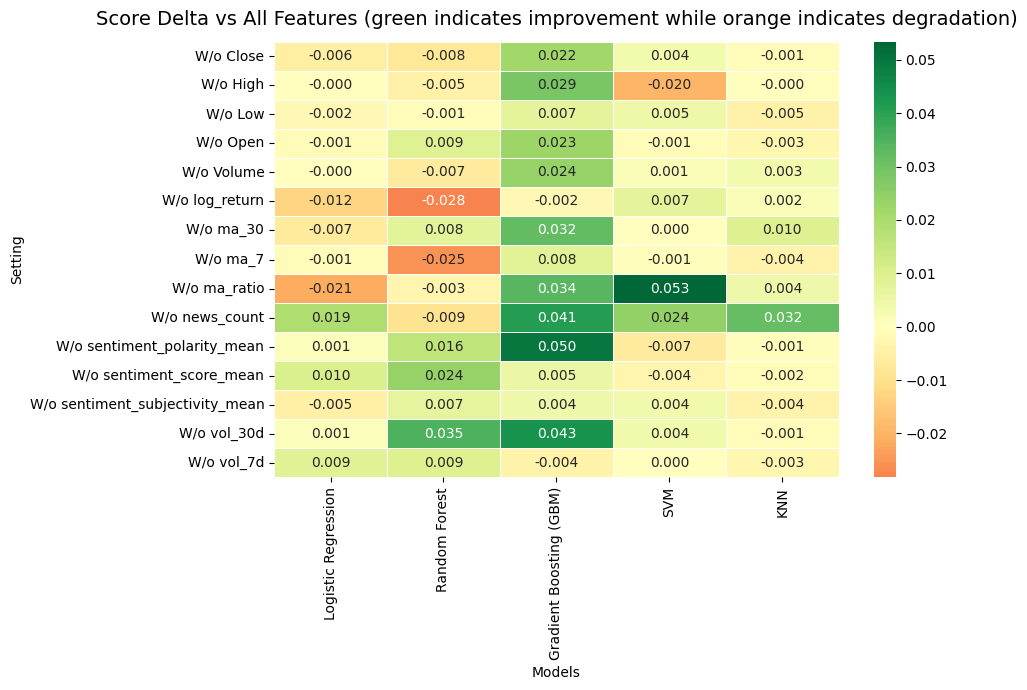

In [42]:
# Delta heatmap: Illustrate the impact of each feature to model performance
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(delta_df, annot=True, fmt=".3f",
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)

ax.set_title('Score Delta vs All Features (green indicates improvement while orange indicates degradation)', fontsize=14, pad=12)
ax.set_xlabel('Models')
plt.tight_layout()

<Axes: xlabel='Model', ylabel='Performance (AUC)'>

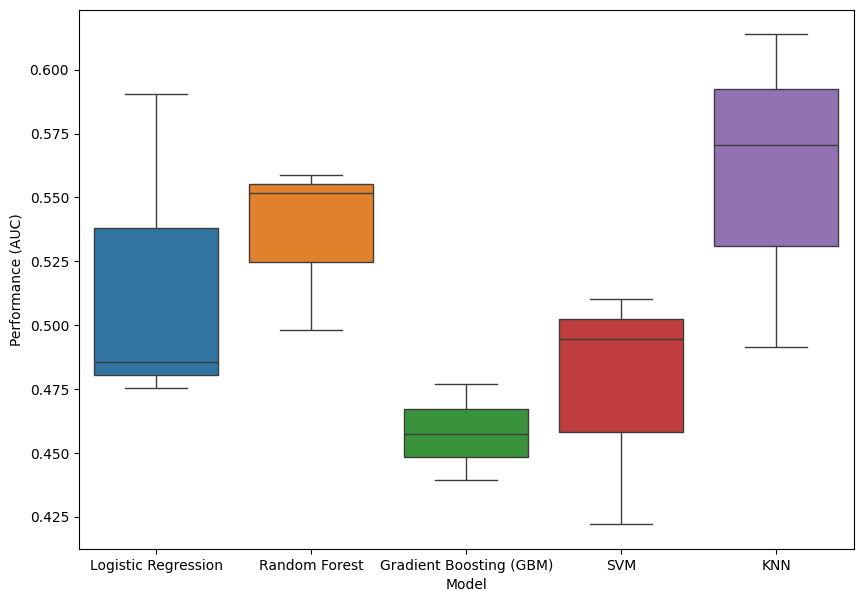

In [60]:
all_models_feat_importance_binary_df
all_rows = []
for dataset in all_models_feat_importance_binary_df['Dataset'].unique().tolist():
    for model in model_cols:
        performance = all_models_feat_importance_binary_df[(all_models_feat_importance_binary_df['Dataset'] == dataset) &
                                                           (all_models_feat_importance_binary_df['Setting'] == 'All features')][model]
        all_rows.append({'Model': model, 'Dataset': dataset, 'Performance (AUC)': performance.values[0]})

tmp_df = pd.DataFrame(all_rows)
tmp_df

plt.subplots(figsize=(10, 7))
ax.set_title('Performance distribution of each model trained with all features', fontsize=14, pad=12)
sns.boxplot(data=tmp_df,y='Performance (AUC)',hue='Model',x='Model')

Importance score from randomforest 


In [61]:
files = os.listdir(DATA_PATH)
task = BINARY_LABEL_COLUMN
seed_everything(INIT_SEED)

result_file_name = "random_forest_feat_importance_binary.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    random_forest_feat_importance_binary_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    random_forest_feat_importance_binary_df = feature_important_score_by_random_forest(files[:3], task,RandomForestClassifier())
    random_forest_feat_importance_binary_df.to_csv(result_path_file,index=False)


random_forest_feat_importance_binary_df.head(32)


INFO: LOADED existing results


,Unnamed: 0,feature,importance
0,9,log_return,0.087080
1,7,sentiment_subjectivity_mean,0.076759
2,6,sentiment_polarity_mean,0.074623
3,4,Volume,0.071608
4,10,vol_7d,0.070806
5,5,sentiment_score_mean,0.068155
6,14,ma_ratio,0.067019
7,0,Close,0.063548
8,11,vol_30d,0.063166
9,12,ma_7,0.062429


Text(0.5, 1.0, 'Importance score of each feature from Random tree')

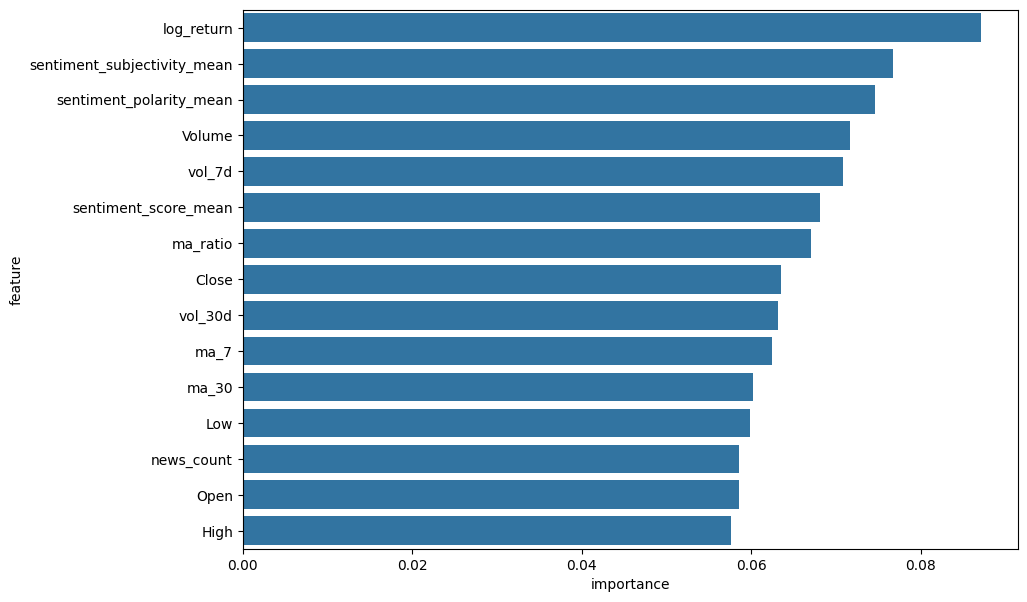

In [71]:
plt.subplots(figsize=(10, 7))
sns.barplot(data=random_forest_feat_importance_binary_df,x='importance',y='feature')
ax.set_title('Importance score of each feature from Random tree', fontsize=14, pad=12)

### 2.2 Regression

In [ ]:

files = os.listdir(DATA_PATH)
task = REGRESSION_LABEL_COLUMN
seed_everything(INIT_SEED)

result_file_name = "all_models_feat_importance_regression.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    all_models_feat_importance_regression_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    all_models_feat_importance_regression_df = drop_feature_experiment(files[:3], task,regression_classfication_model_experience)
    all_models_feat_importance_regression_df.to_csv(result_path_file,index=False)


all_models_feat_importance_regression_df.head(32)



INFO: LOADED existing results


,Unnamed: 0,Linear Regression,Ridge,Lasso,Random Forest,Gradient Boosting (GBM),SVR,Setting,Dataset
0,0,3.244817,3.384688,3.200342,3.816029,3.610714,22.425321,All features,aave.csv
1,1,0.010593,0.017294,0.402760,0.063721,0.066113,0.256526,All features,algorand.csv
2,2,0.330224,0.307513,0.377197,0.355717,0.331044,1.005794,All features,aptos.csv
3,3,3.340712,3.529290,3.438207,4.610418,4.159557,22.427122,W/o Close,aave.csv
4,4,0.011757,0.020929,0.402760,0.065044,0.067863,0.262902,W/o Close,algorand.csv
5,5,0.330827,0.304600,0.380507,0.345278,0.379251,1.008665,W/o Close,aptos.csv
6,6,3.257413,3.436190,3.200342,3.781773,3.656886,22.424914,W/o High,aave.csv
7,7,0.010102,0.018692,0.402760,0.064296,0.068462,0.261126,W/o High,algorand.csv
8,8,0.326114,0.307216,0.377197,0.351806,0.332986,1.008666,W/o High,aptos.csv
9,9,3.274609,3.438590,3.200342,3.919114,3.760226,22.427094,W/o Low,aave.csv


In [ ]:
files = os.listdir(DATA_PATH)
task = REGRESSION_LABEL_COLUMN
seed_everything(INIT_SEED)

result_file_name = "random_forest_feat_importance_regression.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    random_forest_feat_importance_regression_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    random_forest_feat_importance_regression_df = feature_important_score_by_random_forest(files, task,RandomForestRegressor())
    random_forest_feat_importance_regression_df.to_csv(result_path_file,index=False)


random_forest_feat_importance_regression_df.head(32)

INFO: LOADED existing results


,Unnamed: 0,feature,importance
0,0,Close,0.476465
1,1,High,0.225673
2,2,Low,0.140717
3,3,Open,0.090383
4,13,ma_30,0.023700
5,12,ma_7,0.012485
6,11,vol_30d,0.006587
7,4,Volume,0.005272
8,9,log_return,0.005019
9,10,vol_7d,0.004157


In [ ]:
files = os.listdir(DATA_PATH)
task = REGRESSION_LABEL_COLUMN
seed_everything(INIT_SEED)

result_file_name = "mape_arima_regression.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    arima_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    all_data_split = prepare_datasets(files, ALL_FEAT_COLUMN, task)

    all_rows_arima = []
    for train, val, test in tqdm(all_data_split):
        rmse = arima_baseline(train, test)
        all_rows_arima.append({'Dataset' : train.dataset_name, 'RMSE': rmse})
    
    arima_df = pd.DataFrame(all_rows_arima)
    arima_df.to_csv(result_file_name, index= False)


arima_df.head(32)

INFO: LOADED existing results


,Unnamed: 0,Dataset,MAPE
0,0,aave.csv,0.447640
1,1,algorand.csv,0.762574
2,2,aptos.csv,0.309518
3,3,arbitrum.csv,0.410068
4,4,avalanche.csv,0.695222
5,5,axie_infinity.csv,1.360145
6,6,binance_coin.csv,0.684181
7,7,bitcoin.csv,0.392519
8,8,bitcoin_cash.csv,0.848409
9,9,cardano.csv,0.613934
